# Phase 5 · 03 — How stale can the store be, and what runs every month

Two operational questions, finishing Phase 5:

1. **How far can the hot store's ingest lag before GraphSAGE gets worse?** ARCHITECTURE 6.2 planned "AUC-PR vs embedding age", but since Phase 4 GraphSAGE reads live history from Postgres on every request. What can go stale is the *store*: if ingest runs Δ behind, a request sees its card's and merchant's history only up to now − Δ. The answer is the ingest SLA, measured instead of guessed.
2. **What does the monitoring job actually do, month by month?** `python -m fraud.monitoring.run` is what Phase 6 will schedule. Here it is run once per month across 2019 — the same function, with the clock set to each month's first day — to show when it would have paged someone, and why it stays quiet on the stable model.

The staleness replays run in `.venv` (they load GraphSAGE): `python -m fraud.jobs.staleness`. This notebook reads their summary. Kernel: `fraud-monitoring`.

In [1]:
import os, json, datetime as dt, warnings
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from fraud.config import load_params, repo_path
from fraud.monitoring import run as job

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(20); pl.Config.set_tbl_cols(12)
params = load_params()
SAMPLE = 60_000 if os.getenv("FRAUD_NOTEBOOK_SAMPLE") else None
print("mode:", "SAMPLE" if SAMPLE else "FULL")

mode: FULL


## 1 · AUC-PR vs ingest lag

GraphSAGE replayed causally over April–June 2019 (429,456 transactions, 693 frauds) once per lag. A row becomes visible only once it is `lag` old; lag 0 is serving as built and reproduces the full 2019 replay row for row. Differences are paired-bootstrap intervals: the same transactions resampled for both lags.

In [2]:
summary_path = repo_path(params["staleness"]["output_dir"]) / "summary.json"
if not summary_path.exists():
    print("no staleness results yet -- run: .venv/bin/python -m fraud.jobs.staleness")
    staleness = None
else:
    staleness = json.loads(summary_path.read_text())
    print("slice:", staleness["slice"])
    print("lag 0 vs the full replay:", staleness["lag0_vs_full_replay"])
    table = pl.DataFrame([{
        "lag_hours": r["lag_hours"], "auc_pr": r["auc_pr"], "p_at_100": r["precision_at_100"],
        "delta_vs_0": r.get("vs_lag0", {}).get("delta", 0.0),
        "ci_low": r.get("vs_lag0", {}).get("ci_low", 0.0),
        "ci_high": r.get("vs_lag0", {}).get("ci_high", 0.0),
        "p_worse": r.get("vs_lag0", {}).get("p_worse"),
    } for r in staleness["lags"]])
    display(table)

slice: {'start': '2019-04-01 00:01:00', 'end': '2019-06-30 23:59:00', 'rows': 429456, 'frauds': 693}
lag 0 vs the full replay: {'max_abs_diff': 1.7881393432617188e-07, 'mismatches_over_1e-6': 0}


lag_hours,auc_pr,p_at_100,delta_vs_0,ci_low,ci_high,p_worse
f64,f64,f64,f64,f64,f64,f64
0.0,0.550729,0.82,0.0,0.0,0.0,null
1.0,0.624363,0.87,0.073634,0.050742,0.096301,0.0
6.0,0.605122,0.88,0.054393,0.024382,0.080045,0.0
24.0,0.588183,0.92,0.037454,0.00472,0.07109,0.003333
72.0,0.450906,0.86,-0.099823,-0.140007,-0.057572,1.0
168.0,0.577065,0.86,0.026336,-0.015571,0.070036,0.106667


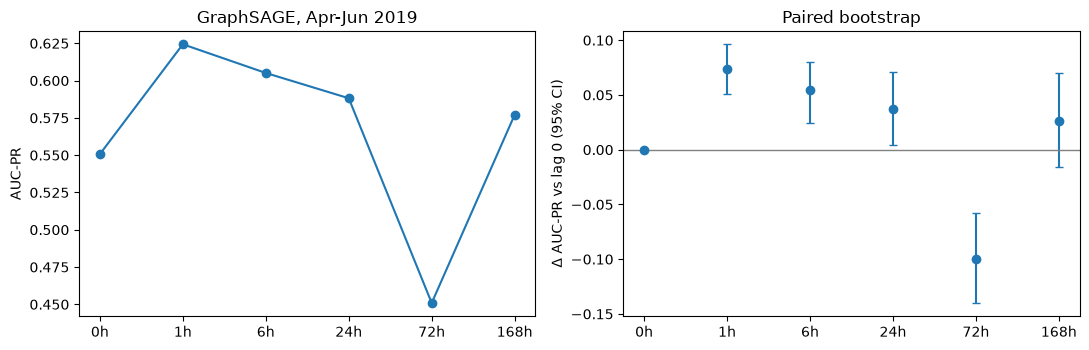

first lag with a significant drop: 72.0 h  ->  largest safe lag measured: 24.0 h


In [3]:
if staleness is not None:
    lags = table["lag_hours"].to_numpy(); x = np.arange(len(lags))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ax[0].plot(x, table["auc_pr"], marker="o")
    ax[0].set_xticks(x, [f"{l:g}h" for l in lags]); ax[0].set_ylabel("AUC-PR"); ax[0].set_title("GraphSAGE, Apr-Jun 2019")
    d, lo, hi = table["delta_vs_0"].to_numpy(), table["ci_low"].to_numpy(), table["ci_high"].to_numpy()
    ax[1].errorbar(x, d, yerr=[d - lo, hi - d], fmt="o", capsize=3)
    ax[1].axhline(0, c="grey", lw=1)
    ax[1].set_xticks(x, [f"{l:g}h" for l in lags]); ax[1].set_ylabel("Δ AUC-PR vs lag 0 (95% CI)")
    ax[1].set_title("Paired bootstrap")
    plt.tight_layout(); plt.show()

    significant = table.filter((pl.col("lag_hours") > 0) & (pl.col("ci_high") < 0))
    sla = (table.filter(pl.col("lag_hours") < significant["lag_hours"].min())["lag_hours"].max()
           if significant.height else table["lag_hours"].max())
    first_bad = significant["lag_hours"].min() if significant.height else None
    print(f"first lag with a significant drop: {first_bad} h  ->  largest safe lag measured: {sla} h")

### Which part of the request does the lag move?

A lagging store changes two inputs at once: the **graph neighbours** (the card's and merchant's recent rows) and the **velocity features** computed from the card's history. Re-running the 1 h lag on one of them at a time, with the other left fresh, says which one produced the effect above.

In [4]:
rows_ = []
for mode in ("both", "graph", "velocity"):
    path = (summary_path if mode == "both"
            else repo_path(params["staleness"]["output_dir"]) / f"lag_{mode}_only" / "summary.json")
    if not path.exists():
        print("missing:", path); continue
    r = next(x for x in json.loads(path.read_text())["lags"] if x["lag_hours"] == 1.0)
    rows_.append({"1 h lag applied to": mode, "auc_pr": r["auc_pr"],
                  "delta_vs_0": r["vs_lag0"]["delta"], "ci_low": r["vs_lag0"]["ci_low"],
                  "ci_high": r["vs_lag0"]["ci_high"]})
decomposition = pl.DataFrame(rows_)
decomposition

1 h lag applied to,auc_pr,delta_vs_0,ci_low,ci_high
str,f64,f64,f64,f64
"""both""",0.624363,0.073634,0.050742,0.096301
"""graph""",0.564487,0.013758,0.005214,0.021761
"""velocity""",0.622798,0.07207,0.052117,0.095253


## 2 · The monitoring job, month by month

`fraud.monitoring.run.monitor_model` with the clock set to the first of each month. Each run sees only the months closed by then, flags degradation against the 2018 level, and alerts only when the flag persists for two consecutive months (decision 25). Realized metrics appear only for months whose labels are complete by that date.

In [5]:
as_of_dates = [dt.datetime(2019, m, 1) for m in range(2, 13)]
timeline = []
for model in job.MODELS:
    frames = job.load_frames(params, model, sample=SAMPLE)
    for as_of in as_of_dates:
        r = job.monitor_model(params, model, as_of, frames=frames)
        timeline.append({k: r[k] for k in ("model", "latest_month", "latest_estimate",
                                           "latest_relative_change", "alert", "months_flagged",
                                           "months_alerting", "label_ready_months")}
                        | {"as_of": as_of.date()})
timeline = pl.DataFrame(timeline)
timeline.select("model", "as_of", "latest_month", pl.col("latest_estimate").round(3),
                pl.col("latest_relative_change").round(3), "alert", "label_ready_months")

model,as_of,latest_month,latest_estimate,latest_relative_change,alert,label_ready_months
str,date,str,f64,f64,bool,i64
"""xgboost""",2019-02-01,"""2019-01-01""",0.309,-0.206,false,0
"""xgboost""",2019-03-01,"""2019-02-01""",0.335,-0.137,false,0
"""xgboost""",2019-04-01,"""2019-03-01""",0.312,-0.197,false,0
"""xgboost""",2019-05-01,"""2019-04-01""",0.3,-0.229,true,0
"""xgboost""",2019-06-01,"""2019-05-01""",0.341,-0.122,false,2
"""xgboost""",2019-07-01,"""2019-06-01""",0.337,-0.133,false,3
"""xgboost""",2019-08-01,"""2019-07-01""",0.289,-0.258,false,4
"""xgboost""",2019-09-01,"""2019-08-01""",0.321,-0.173,true,5
"""xgboost""",2019-10-01,"""2019-09-01""",0.325,-0.164,true,6


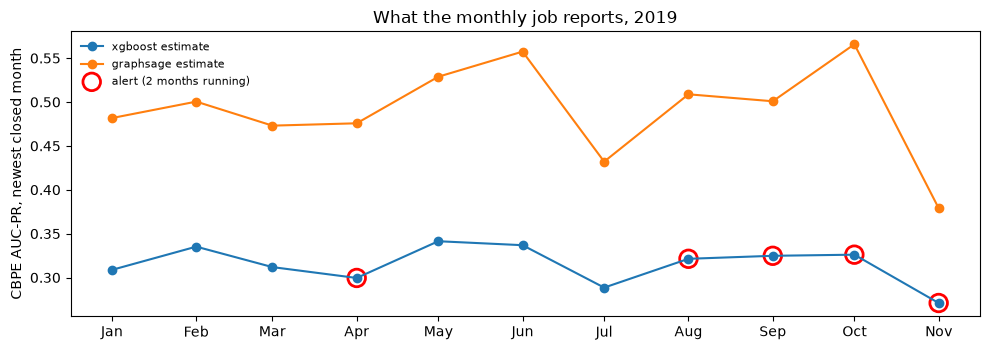

runs in 2019: [('xgboost', 11), ('graphsage', 11)]


model,first_alert_on,runs_alerting
str,date,u32
"""xgboost""",2019-05-01,5


In [6]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for model, part in timeline.group_by("model", maintain_order=True):
    month = pl.Series(part["latest_month"]).str.to_date()
    line, = ax.plot(month, part["latest_estimate"], marker="o", label=f"{model[0]} estimate")
    alerts = part.filter(pl.col("alert"))
    ax.scatter(pl.Series(alerts["latest_month"]).str.to_date(), alerts["latest_estimate"], s=160,
               facecolors="none", edgecolors="red", linewidths=2)
ax.scatter([], [], s=160, facecolors="none", edgecolors="red", linewidths=2, label="alert (2 months running)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.set_ylabel("CBPE AUC-PR, newest closed month")
ax.set_title("What the monthly job reports, 2019"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

first = (timeline.filter("alert").group_by("model").agg(pl.col("as_of").min().alias("first_alert_on"),
                                                         pl.len().alias("runs_alerting")))
print("runs in 2019:", timeline.group_by("model").len().rows())
first

## 3 · Freshness, read from the live store

The freshness SLI is the gap between the job's clock and the newest row the serving path can see. Its threshold (`monitoring.freshness.hot_store_max_hours`) is the staleness result above. The store currently holds the Phase 4 latency slice (seeded history plus the 3,000 replayed June 2019 transactions), so the SLI is shown at a few clock times after its newest row.

In [7]:
try:
    from fraud.api import store
    conn = store.connect()
    with conn.cursor() as cur:
        cur.execute("select max(ts) as ts, count(*) as n from transaction_events")
        newest = cur.fetchone()
    newest_ts = newest["ts"].replace(tzinfo=None)
    print(f"hot store: {newest['n']:,} rows, newest {newest_ts}")
    probes = [newest_ts + dt.timedelta(minutes=m) for m in (15, 45, 90, 600)]
    sli = pl.concat([job.freshness(conn, t, params).with_columns(pl.lit(t).alias("clock")) for t in probes])
    conn.close()
    display(sli.select("clock", "metric", pl.col("value").round(2), "upper_threshold", "alert"))
except Exception as exc:          # no database is not a failure for the experiment
    print("database unavailable, freshness not shown:", type(exc).__name__, exc)

hot store: 37,031 rows, newest 2019-06-03 14:16:00


clock,metric,value,upper_threshold,alert
datetime[μs],str,f64,f64,bool
2019-06-03 14:31:00,"""freshness_hot_store_hours""",0.25,24.0,false
2019-06-03 15:01:00,"""freshness_hot_store_hours""",0.75,24.0,false
2019-06-03 15:46:00,"""freshness_hot_store_hours""",1.5,24.0,false
2019-06-04 00:16:00,"""freshness_hot_store_hours""",10.0,24.0,false


## Reading the results (full run, 3 Oct 2026)

**A lagging store did not hurt GraphSAGE — up to a point, it helped.** Over April–June 2019 (429,456 transactions, 693 frauds; lag 0 reproduces the full replay row for row), a 1 h ingest lag *raised* AUC-PR from 0.551 to 0.624 (+0.074, 95% CI +0.051 to +0.096); 6 h and 24 h also beat lag 0. 72 h cost −0.10 [−0.14, −0.06]; 168 h was back level. The curve is not monotonic, so the 72 h point should be replicated on another slice before anything leans on it.

**The gain is velocity, not the graph.** Applying the 1 h lag to one consumer at a time: graph neighbours only, +0.014; velocity only, **+0.072** — nearly all of it. Hiding the most recent hour from the velocity features makes 2019 scoring better. Velocity is computed identically offline and online (the skew test), so this is not a serving bug: it is the short-window velocity signal the model learned on ≤2017 data meaning something different in 2019. Notebook 01 flagged exactly this — `velocity_seconds_since_last` drifts in 2019. The fix belongs to the model (retrain, or review the 1 h and seconds-since-last features), not to the ingest pipeline.

**So the ingest SLA is 24 h, measured.** No lag up to 24 h made GraphSAGE worse; `monitoring.freshness.hot_store_max_hours` is set to that. It is a ceiling, not a target — the drift finding argues for fixing the features, not for lagging ingest on purpose.

**The monthly job pages for the right model.** Run with the clock at the first of each month, it alerts on XGBoost from **1 May 2019** (March and April both flagged) and in 5 of 11 runs; it **never alerts on GraphSAGE**, whose single weak months are absorbed by the two-month persistence rule. Realized metrics appear in each run only for months whose labels are complete — roughly three months behind the estimate.

**Freshness is read from the live store**, and alerts once its newest row is more than 24 h behind the job's clock.